## 1. Import libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

## 2. Load dataset

In [22]:
df = pd.read_csv("diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 3.  Replace biologically unrealistic zeros with missing values

In [23]:
zero_as_missing_cols = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df[zero_as_missing_cols] = df[zero_as_missing_cols].replace(0, np.nan)

print(df.isna().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


## 4. Separate features and target

In [24]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Class distribution:")
print(y.value_counts(normalize=True))

Class distribution:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


## 5. Train-test split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (614, 8)
X_test: (154, 8)


## 6. Define model pipelines

In [26]:
models = {
    "Logistic Regression": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Decision Tree": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeClassifier(
            max_depth=5,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "KNN": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(
            n_neighbors=7
        ))
    ]),

    "SVM": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            probability=True,
            class_weight="balanced",
            random_state=42
        ))
    ])
}

## 7. Cross-validation comparison

In [27]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = []

for name, pipeline in models.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    cv_results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1-score": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by="F1-score",
    ascending=False
)

print(cv_results_df.round(4))

c:\Users\Dokhtar-e Zahra\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Dokhtar-e Zahra\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Dokhtar-e Zahra\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Dokhtar-e Zahra\AppData\Local\Programs\Python\

                 Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
4                  SVM    0.7605     0.6372  0.7617    0.6902   0.8371
2        Random Forest    0.7622     0.6461  0.7102    0.6760   0.8267
0  Logistic Regression    0.7622     0.6486  0.7010    0.6724   0.8444
1        Decision Tree    0.7182     0.5705  0.7897    0.6614   0.7712
3                  KNN    0.7345     0.6435  0.5700    0.6005   0.7983


## 8. Select best model

In [28]:
best_model_name = cv_results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("Best model based on cross-validation F1-score:", best_model_name)

Best model based on cross-validation F1-score: SVM


## 9. Train best model on full training data

In [29]:
best_model.fit(X_train, y_train)

c:\Users\Dokhtar-e Zahra\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Pregnancies','Glucose','BloodPressure',...,'BMI', 'DiabetesPedigreeFunction','Age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For str

## 10. Evaluate on test data

In [30]:
y_pred = best_model.predict(X_test)

if hasattr(best_model.named_steps["model"], "predict_proba"):
    y_proba = best_model.predict_proba(X_test)[:, 1]
else:
    y_proba = None

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test Precision:", precision_score(y_test, y_pred))
print("Test Recall:", recall_score(y_test, y_pred))
print("Test F1-score:", f1_score(y_test, y_pred))

if y_proba is not None:
    print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Non-diabetic", "Diabetic"]
))

Test Accuracy: 0.7272727272727273
Test Precision: 0.5909090909090909
Test Recall: 0.7222222222222222
Test F1-score: 0.65
Test ROC-AUC: 0.8138888888888889

Classification Report:
              precision    recall  f1-score   support

Non-diabetic       0.83      0.73      0.78       100
    Diabetic       0.59      0.72      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.75      0.73      0.73       154



## 11. Confusion matrix

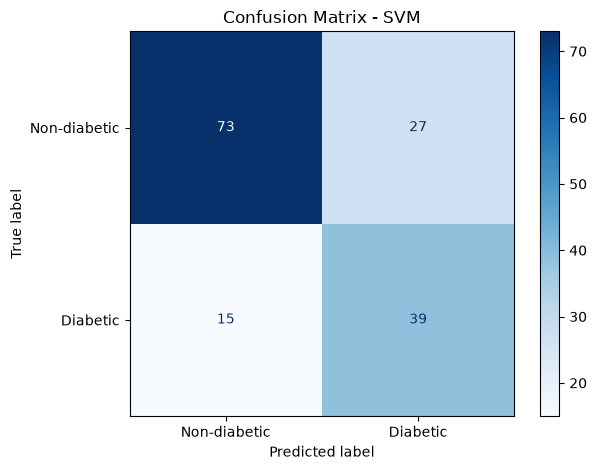

In [31]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-diabetic", "Diabetic"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - " + best_model_name)
plt.tight_layout()
plt.show()

## 12. ROC curve and Precision-Recall curve

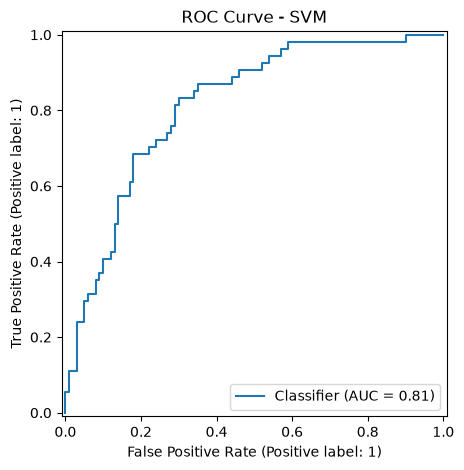

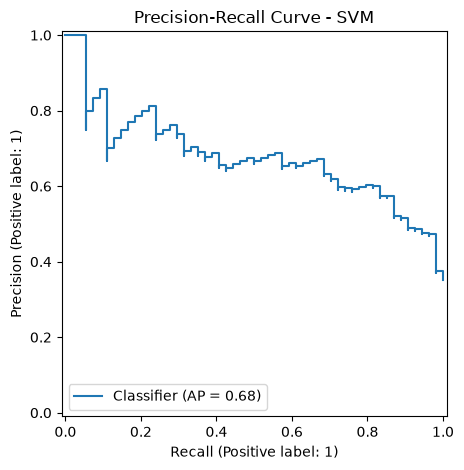

In [32]:
if y_proba is not None:
    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.title("ROC Curve - " + best_model_name)
    plt.tight_layout()
    plt.show()

    PrecisionRecallDisplay.from_predictions(y_test, y_proba)
    plt.title("Precision-Recall Curve - " + best_model_name)
    plt.tight_layout()
    plt.show()

## 13. Hyperparameter tuning - Random Forest

In [33]:
rf_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ))
])

rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest parameters:")
print(rf_grid.best_params_)

print("Best CV F1-score:")
print(rf_grid.best_score_)

Best Random Forest parameters:
{'model__max_depth': 5, 'model__min_samples_leaf': 2, 'model__min_samples_split': 10, 'model__n_estimators': 200}
Best CV F1-score:
0.7019817663135635


In [34]:
# Evaluate tuned Random Forest
best_rf = rf_grid.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Non-diabetic", "Diabetic"]
))

print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

              precision    recall  f1-score   support

Non-diabetic       0.86      0.71      0.78       100
    Diabetic       0.59      0.78      0.67        54

    accuracy                           0.73       154
   macro avg       0.72      0.74      0.72       154
weighted avg       0.76      0.73      0.74       154

ROC-AUC: 0.8198148148148148


## 14. Threshold tuning

In [35]:
thresholds = np.arange(0.1, 0.9, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_proba_rf >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1-score": f1_score(y_test, y_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df.round(4))


    Threshold  Precision  Recall  F1-score
0        0.10     0.4000  1.0000    0.5714
1        0.15     0.4344  0.9815    0.6023
2        0.20     0.4643  0.9630    0.6265
3        0.25     0.4951  0.9444    0.6497
4        0.30     0.5158  0.9074    0.6577
5        0.35     0.5517  0.8889    0.6809
6        0.40     0.5663  0.8704    0.6861
7        0.45     0.5769  0.8333    0.6818
8        0.50     0.5915  0.7778    0.6720
9        0.55     0.6333  0.7037    0.6667
10       0.60     0.6538  0.6296    0.6415
11       0.65     0.6279  0.5000    0.5567
12       0.70     0.6857  0.4444    0.5393
13       0.75     0.7083  0.3148    0.4359
14       0.80     0.7857  0.2037    0.3235
15       0.85     1.0000  0.0370    0.0714


In [36]:
# Select threshold with best F1-score
best_threshold = threshold_df.sort_values(
    by="F1-score",
    ascending=False
).iloc[0]["Threshold"]

print("Best threshold:", best_threshold)

Best threshold: 0.40000000000000013


              precision    recall  f1-score   support

Non-diabetic       0.90      0.64      0.75       100
    Diabetic       0.57      0.87      0.69        54

    accuracy                           0.72       154
   macro avg       0.73      0.76      0.72       154
weighted avg       0.78      0.72      0.73       154



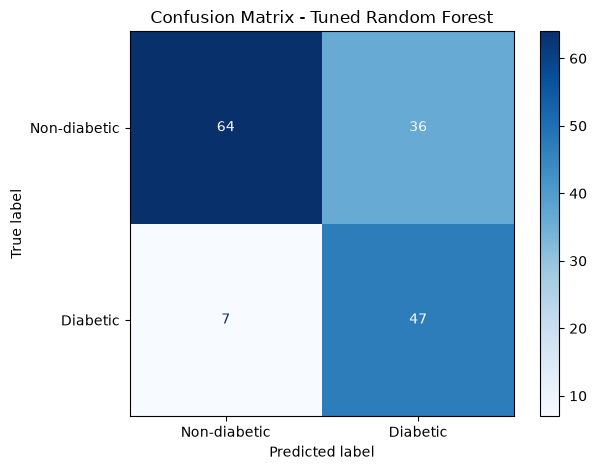

In [37]:
# Final prediction using optimized threshold
y_pred_final = (y_proba_rf >= best_threshold).astype(int)

print(classification_report(
    y_test,
    y_pred_final,
    target_names=["Non-diabetic", "Diabetic"]
))

cm = confusion_matrix(y_test, y_pred_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-diabetic", "Diabetic"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Tuned Random Forest")
plt.tight_layout()
plt.show()